In [20]:
import torch
import sys
print("Interpreter:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Interpreter: d:\maga25\VKRTimeSeries\.venv\Scripts\python.exe
CUDA available: True
GPU name: NVIDIA GeForce GTX 1660


In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [22]:
import random

import numpy as np
import pandas as pd
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

In [23]:
# воспроизводимость
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [24]:
dataset = "data/ETTh1.csv"

num_workers = 6  # кол-во потоков для загрузки данных
batch_size = 32  # кол-во одновременно обрабатываемых образцов данных
context_length = 512 # длина окна
forecast_horizon = 96 # длина предсказания
patch_length = 12 # размер патча (число временных шагов по всем признакам)

timestamp_column = "date"
id_columns = []
forecast_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
train_start_index = None
train_end_index = 12 * 30 * 24 # в обучении 1 год данных (12мес * 30дн * 24ч)

# индекс начала валидации сдвинут на context_length, чтобы оценить точность с начала валидационных данных
valid_start_index = 12 * 30 * 24 - context_length
valid_end_index = 12 * 30 * 24 + 4 * 30 * 24

# индекс начала теста сдвинут на context_length, чтобы оценить точность с начала тестовых данных
test_start_index = 12 * 30 * 24 + 4 * 30 * 24 - context_length
test_end_index = 12 * 30 * 24 + 8 * 30 * 24

data = pd.read_csv(
    dataset,
    parse_dates=[timestamp_column], # тип datetime
)

train_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=train_start_index,
    end_index=train_end_index,
)
valid_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=valid_start_index,
    end_index=valid_end_index,
)
test_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=test_start_index,
    end_index=test_end_index,
)

tsp = TimeSeriesPreprocessor(
    timestamp_column=timestamp_column,
    id_columns=id_columns,
    target_columns=forecast_columns,
    scaling=True,
)
tsp.train(train_data) # вычисление среднего и дисперсии


# преобразование датафреймов в набор окон
train_dataset = ForecastDFDataset(
    tsp.preprocess(train_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)
valid_dataset = ForecastDFDataset(
    tsp.preprocess(valid_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)
test_dataset = ForecastDFDataset(
    tsp.preprocess(test_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)


In [ ]:
import itertools
from transformers import (
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# перебор параметров
param_grid = {
    'learning_rate': [0.001, 0.0002], # скорость обучения
    'd_model': [128, 256], # размерность эмбеддингов
    'num_hidden_layers': [3, 4], # количество слоев энкодера
    'dropout': [0.2, 0.3], # регуляризация
    'patch_length': [12, 24] # длина патча
}

keys = list(param_grid.keys())
values = [param_grid[k] for k in keys]
combinations = list(itertools.product(*values))

results = []

best_loss = float('inf')
best_model_path = ""

# перебор параметров
for cur in combinations:
    lr, d_model, num_hidden_layers, dropout, patch_length = cur
    print(f"\nПроверка: lr={lr}, d_model={d_model}, layers={num_hidden_layers}, dropout={dropout}, patch_len={patch_length}")

    # описание архитектуры модели
    config = PatchTSTConfig(
        num_input_channels=len(forecast_columns),
        context_length=context_length,
        patch_length=patch_length,
        prediction_length=forecast_horizon,
        patch_stride=patch_length, # patch_stride = patch_length (неперекрывающиеся)
        d_model=d_model, # размер скрытого состояния (каждый патч преобразуется в вектор этой размерности)
        num_attention_heads=8, # способность модели улавливать разные зависимости между патчами
        num_hidden_layers=num_hidden_layers, # количество слоев Transformer (энкодеров) 
        ffn_dim=d_model * 4, # размерность промежуточного слоя Feed-Forward Network (FFN) 
        dropout=dropout,
        head_dropout=dropout,
        pooling_type=None,
        channel_attention=False,
        scaling="std", 
        loss="mse", # функция потерь
        pre_norm=True,
        norm_type="batchnorm",
        do_mask_input=False,
        mask_ratio=0.0,
    )
    model = PatchTSTForPrediction(config=config)

    # параметры обучения
    train_args = TrainingArguments(
        output_dir=f"./checkpoint/exp_lr{lr}_d{d_model}_lay{num_hidden_layers}_do{dropout}_p{patch_length}",
        learning_rate=lr, # скорость обучения
        num_train_epochs=20, # число эпох
        do_eval=True,
        eval_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=num_workers,
        logging_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True, # после завершения обучения загружается лучшая модель
        metric_for_best_model="eval_loss", # ошибка на валидации
        greater_is_better=False,
        label_names=["future_values"]
    )

    # ранняя остановка обучения
    early_stopping = EarlyStoppingCallback(
        early_stopping_patience=5, # если на протяжении 5 эпох ошибка не уменьшалась, обучение прекращается
        early_stopping_threshold=0.001,
    )

    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        callbacks=[early_stopping],
    )

    trainer.train()

    # оценка на тесте
    test_metrics = trainer.evaluate(test_dataset)
    test_loss = test_metrics['eval_loss']
    print(f"Ошибка на тесте: {test_loss:.4f}")

    # сохранение лучшей модели
    if test_loss < best_loss:
        best_loss = test_loss
        model.save_pretrained("./best_patchtst_etth1_model")
        tsp.save_pretrained("./best_tsp_etth1_preprocessor")

    results.append((test_loss, lr, d_model, num_hidden_layers, dropout, patch_length))

    # очищение памяти
    del model, trainer
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 5614.65it/s]
INFO:p-11132:t-34528:processor.py:get_feature_extractor_dict:loading configuration file ./best_tsp_etth1_preprocessor\preprocessor_config.json


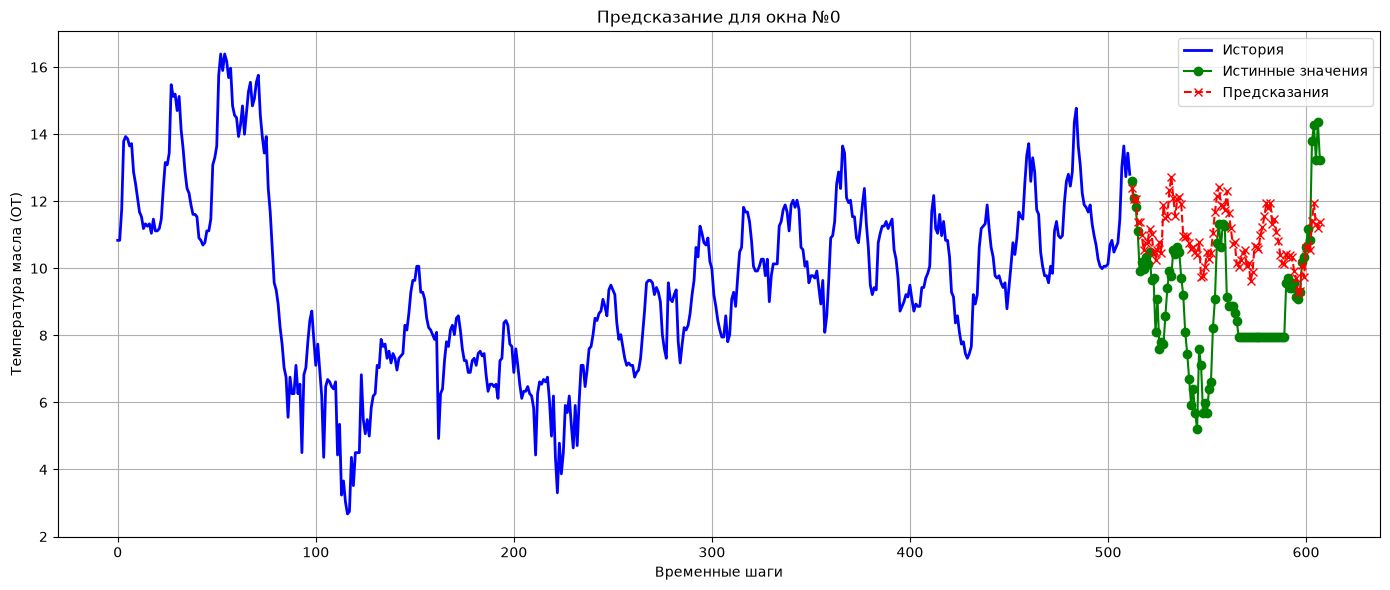

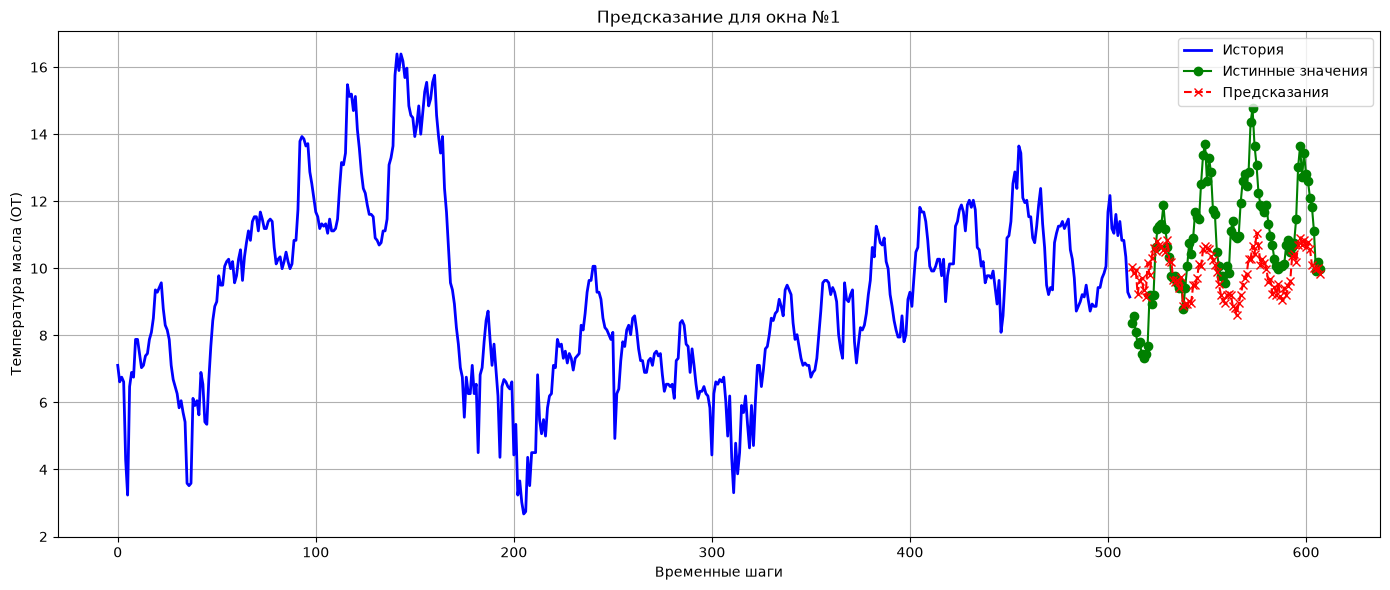

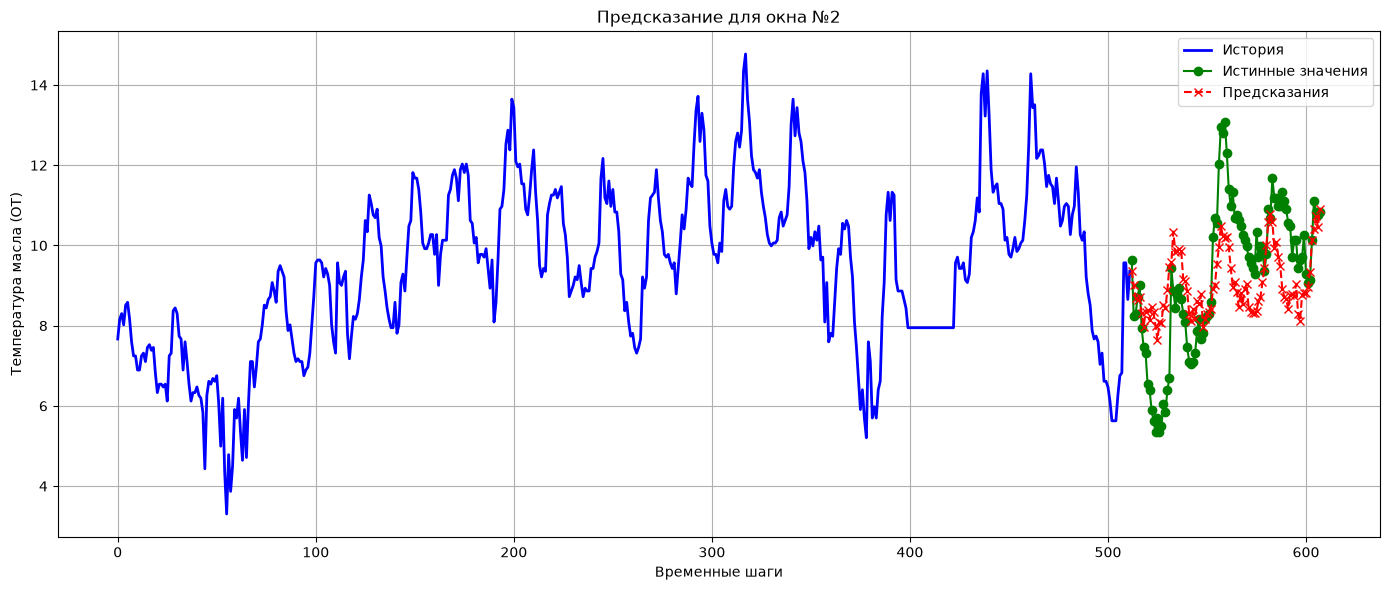

MSE : 4.5182
MAE : 1.6216


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_path = "./best_patchtst_etth1_model"
preprocessor_path = "./best_tsp_etth1_preprocessor"

model = PatchTSTForPrediction.from_pretrained(model_path)
tsp = TimeSeriesPreprocessor.from_pretrained(preprocessor_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# предсказания
trainer = Trainer(model=model)
test_results = trainer.predict(test_dataset)
preds = test_results.predictions
if isinstance(preds, tuple):
    preds = preds[0]

all_preds = []
all_labels = []

with torch.no_grad():
    for sample in test_dataset:
        past = sample['past_values'].unsqueeze(0).to(device)
        output = model(past_values=past)
        pred = output.prediction_outputs.cpu().numpy()
        all_preds.append(pred)
        all_labels.append(sample['future_values'].numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.numpy()
    return np.array(x)

# объект для обратного масштабирования
scaler = list(tsp.target_scaler_dict.values())[0]

col_name = "OT"
col_idx = forecast_columns.index(col_name)
indices = random.sample(range(600), 3)

for num, idx in enumerate(indices):
    sample = test_dataset[idx]
    context = to_numpy(sample['past_values']) # история
    true_future = to_numpy(sample['future_values']) # истинные значения
    pred_future = all_preds[idx] # предсказания 

    # обратное масштабирование
    context_inv = scaler.inverse_transform(context)
    true_inv = scaler.inverse_transform(true_future)
    pred_inv = scaler.inverse_transform(pred_future)

    plt.figure(figsize=(14, 6))
    x_context = np.arange(context_length)
    x_future = np.arange(context_length, context_length + forecast_horizon)

    plt.plot(x_context, context_inv[:, col_idx], label='История', color='blue', linewidth=2)
    plt.plot(x_future, true_inv[:, col_idx], label='Истинные значения', color='green', marker='o', linestyle='-', linewidth=1.5)
    plt.plot(x_future, pred_inv[:, col_idx], label='Предсказания', color='red', marker='x', linestyle='--', linewidth=1.5)

    plt.xlabel('Временные шаги')
    plt.ylabel('Температура масла (OT)')
    plt.title(f'Предсказание для окна №{num}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

all_true_flat = all_labels.reshape(-1, len(forecast_columns))
all_pred_flat = all_preds.reshape(-1, len(forecast_columns))

all_true_inv = scaler.inverse_transform(all_true_flat)
all_pred_inv = scaler.inverse_transform(all_pred_flat)

true_ot = all_true_inv[:, col_idx]
pred_ot = all_pred_inv[:, col_idx]

mse = mean_squared_error(true_ot, pred_ot)
mae = mean_absolute_error(true_ot, pred_ot)

print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")